In [1]:
# Load Data, Handle NaNs, and Define Features/Target

# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Import scikit-learn for data processing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# --- Load the data, using the first row as the header ---
df = pd.read_csv('/kaggle/input/pooled-server-metrics-psm/data/train.csv')
# --- DIAGNOSTIC STEP: Check for missing values ---
print("Checking for missing values in each column:")
print(df.isnull().sum())

# --- THE FIX: Handle missing values using Forward Fill ---
# ffill carries the last valid observation forward.
print("\nFilling missing values using forward fill...")
df.ffill(inplace=True)

# As a safety net, if any NaNs remain at the very start of the file, fill them with 0.
df.fillna(0, inplace=True)

print("\nChecking again for missing values after filling:")
print(df.isnull().sum())


# --- Define Features (X) and Target (y) ---
# The target variable is 'feature_0'.
y = df['feature_0'].values

# The features are all 'feature_x' columns from 0 to 24.
feature_cols = [f'feature_{i}' for i in range(25)]
X = df[feature_cols].values

print(f"\nFeatures shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

# Verification check
if X.shape[1] == 25:
    print("\nSuccessfully loaded 25 features.")
else:
    print(f"\nWarning: Loaded {X.shape[1]} features, expected 25. Please check the data.")

2025-09-03 06:49:35.402841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756882175.767876      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756882175.868034      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Checking for missing values in each column:
timestamp_(min)       0
feature_0             0
feature_1             0
feature_2             0
feature_3             0
feature_4           202
feature_5           249
feature_6           563
feature_7            47
feature_8            47
feature_9             0
feature_10           47
feature_11            0
feature_12            0
feature_13          249
feature_14          202
feature_15            0
feature_16            0
feature_17            0
feature_18          202
feature_19            0
feature_20            0
feature_21         2136
feature_22          204
feature_23            0
feature_24           47
dtype: int64

Filling missing values using forward fill...

Checking again for missing values after filling:
timestamp_(min)    0
feature_0          0
feature_1          0
feature_2          0
feature_3          0
feature_4          0
feature_5          0
feature_6          0
feature_7          0
feature_8          0
feature_9    

In [2]:
# Feature Scaling

# --- Scale the features to a range of [0, 1] ---
feature_scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = feature_scaler.fit_transform(X)

# --- Scale the target variable to a range of [0, 1] ---
# We use a separate scaler for the target for easier inverse transformation later
# We also need to reshape y to be a 2D array for the scaler
target_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaled = target_scaler.fit_transform(y.reshape(-1, 1))

print("Feature data scaled. Shape:", X_scaled.shape)
print("Target data scaled. Shape:", y_scaled.shape)

Feature data scaled. Shape: (132481, 25)
Target data scaled. Shape: (132481, 1)


In [3]:
# Create Time-Series Sequences

def create_sequences(features, target, look_back=60):
    """
    Creates sequences of historical data for time-series forecasting.
    """
    X_seq, y_seq = [], []
    for i in range(len(features) - look_back):
        # The input sequence is a chunk of 'look_back' historical feature sets
        X_seq.append(features[i:(i + look_back)])
        # The output is the single target value that immediately follows the chunk
        y_seq.append(target[i + look_back])
    return np.array(X_seq), np.array(y_seq)

# Define the look-back period (how many past time steps to use for prediction)
# 60 means we will use the features from the past 60 minutes to predict the next minute.
look_back = 60

# Create the sequences from our scaled data
X_sequences, y_sequences = create_sequences(X_scaled, y_scaled, look_back)

print(f"Shape of X_sequences (input sequences): {X_sequences.shape}")
print(f"Shape of y_sequences (output values): {y_sequences.shape}")

Shape of X_sequences (input sequences): (132421, 60, 25)
Shape of y_sequences (output values): (132421, 1)


In [4]:
# Build the LSTM Model

# Get the number of features from the shape of our sequence data
num_features = X_sequences.shape[2] # This should be 25

model = Sequential()

# Add a first LSTM layer.
# `return_sequences=True` is needed because we are stacking another LSTM layer.
# `input_shape` must be (timesteps, num_features).
model.add(LSTM(units=50, return_sequences=True, input_shape=(look_back, num_features)))
model.add(Dropout(0.2)) # Dropout helps prevent overfitting

# Add a second LSTM layer.
# No need for `return_sequences=True` as the next layer is a Dense layer.
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Add a Dense output layer with 1 unit to predict our single target value.
model.add(Dense(units=1))

# Compile the model with the Adam optimizer and Mean Squared Error loss function.
model.compile(optimizer='adam', loss='mean_squared_error')

# Display the model's architecture.
model.summary()

I0000 00:00:1756882198.277950      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756882198.278674      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        15,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,451 (138.48 KB)

 Trainable params: 35,451 (138.48 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the LSTM Model

# Perform a chronological split of the data (e.g., 80% for training, 20% for testing).
train_size = int(len(X_sequences) * 0.8)

X_train, X_test = X_sequences[0:train_size], X_sequences[train_size:]
y_train, y_test = y_sequences[0:train_size], y_sequences[train_size:]

print(f"Number of training sequences: {len(X_train)}")
print(f"Number of testing sequences: {len(X_test)}")

# Define an EarlyStopping callback. This will stop the training process
# if the validation loss doesn't improve for a set number of epochs (patience).
# It also restores the best model weights found during training.
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# --- Train the model! ---
# The history object will store the training and validation loss for each epoch.
history = model.fit(
    X_train,
    y_train,
    epochs=100,             # Set a high number of epochs; EarlyStopping will find the best one.
    batch_size=64,          # A batch size of 64 or 128 is good for GPUs.
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1               # Set to 1 to see the progress bar.
)

Number of training sequences: 105936
Number of testing sequences: 26485
Epoch 1/100


I0000 00:00:1756882205.461181      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


1656/1656 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0087 - val_loss: 7.6074e-04
Epoch 2/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.0015 - val_loss: 4.8059e-04
Epoch 3/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 6.7620e-04 - val_loss: 1.6802e-04
Epoch 4/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 3.1931e-04 - val_loss: 1.6478e-04
Epoch 5/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 2.5717e-04 - val_loss: 1.1419e-04
Epoch 6/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 2.3783e-04 - val_loss: 7.5341e-05
Epoch 7/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 2.2293e-04 - val_loss: 1.1440e-04
Epoch 8/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 2.2486e-04 - val_loss: 2.9964e-04
Epoch 9/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 2.2372e-04 - val_loss: 1.5225e-04
Epoch 10/100
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 2.0657e-04 - val_loss: 2.3682e-04
Epoch 11/100
1656/1656 ━━━━━━━━━━━━━━━

828/828 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Test RMSE: 0.00318


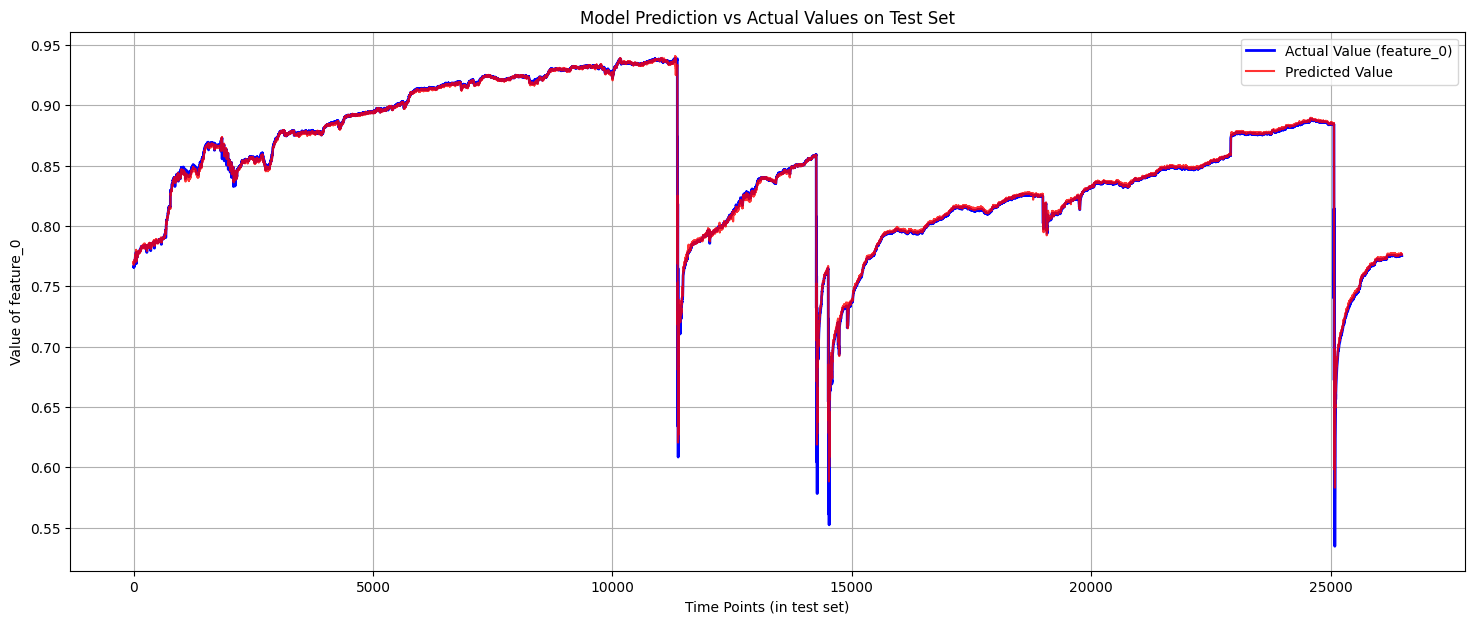

In [6]:
# Evaluate and Visualize Results of the LSTM Model

# Make predictions on the test set. The output will be scaled.
predictions_scaled = model.predict(X_test)

# --- Inverse transform the predictions and actuals to their original scale ---
# This is crucial for interpreting the results and the error metric.
# We use the 'target_scaler' that was fitted on our 'feature_0' column.
predictions = target_scaler.inverse_transform(predictions_scaled)
y_test_actual = target_scaler.inverse_transform(y_test)

# Calculate the Root Mean Squared Error (RMSE) on the original scale.
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Test RMSE: {rmse:.5f}')

# --- Visualize the results ---
plt.figure(figsize=(18, 7))
plt.plot(y_test_actual, color='blue', label='Actual Value (feature_0)', linewidth=2)
plt.plot(predictions, color='red', label='Predicted Value', alpha=0.8)
plt.title('Model Prediction vs Actual Values on Test Set')
plt.xlabel('Time Points (in test set)')
plt.ylabel('Value of feature_0')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Create a Feature Extraction Model from the LSTM

from tensorflow.keras.models import Model
import xgboost as xgb

# We will create a new model that outputs the features from the second-to-last layer
# (the last LSTM layer before the final Dense prediction layer).
# The name 'lstm_2' might vary, check model.summary() for the correct name.
# Let's find the correct layer name automatically.
second_last_layer_name = model.layers[-2].name
print(f"Extracting features from layer: '{second_last_layer_name}'")

# Create the feature extractor model
feature_extractor = Model(inputs=model.inputs, outputs=model.get_layer(second_last_layer_name).output)

# Now, use this model to extract features from our training and testing sequences
print("\nExtracting features from X_train and X_test...")
X_train_features = feature_extractor.predict(X_train)
X_test_features = feature_extractor.predict(X_test)

print(f"Shape of extracted training features: {X_train_features.shape}")
print(f"Shape of extracted testing features: {X_test_features.shape}")

Extracting features from layer: 'dropout_1'

Extracting features from X_train and X_test...
   1/3311 ━━━━━━━━━━━━━━━━━━━━ 12:30 227ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 60, 25))
  warnings.warn(msg)


3292/3311 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 60, 25))
  warnings.warn(msg)


3311/3311 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
828/828 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Shape of extracted training features: (105936, 50)
Shape of extracted testing features: (26485, 50)


In [8]:
# Train an XGBoost Regressor

# --- THE FIX ---
# Instead of manually slicing the original 'y' array, we will simply
# inverse transform y_train and y_test, which are already correctly sliced.
# This guarantees the shapes will match perfectly.

print("Preparing target variables for XGBoost...")
y_train_for_xgb = target_scaler.inverse_transform(y_train).flatten()
y_test_for_xgb = target_scaler.inverse_transform(y_test).flatten()

print(f"Shape of X_train_features: {X_train_features.shape}")
print(f"Shape of y_train_for_xgb: {y_train_for_xgb.shape}")
print(f"Shape of X_test_features: {X_test_features.shape}")
print(f"Shape of y_test_for_xgb: {y_test_for_xgb.shape}")

print("\nTraining XGBoost model...")
# Initialize and train the XGBoost Regressor
# These hyperparameters are a good starting point for GPU training
xgb_regressor = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    objective='reg:squarederror',
    tree_method='gpu_hist',  # Use the GPU
    early_stopping_rounds=50, # Stop if validation error doesn't improve
    n_jobs=-1
)

# XGBoost needs a validation set to use early stopping
xgb_regressor.fit(
    X_train_features,
    y_train_for_xgb,
    eval_set=[(X_test_features, y_test_for_xgb)],
    verbose=False # Set to True if you want to see the training progress
)

print("XGBoost model training complete.")

Preparing target variables for XGBoost...
Shape of X_train_features: (105936, 50)
Shape of y_train_for_xgb: (105936,)
Shape of X_test_features: (26485, 50)
Shape of y_test_for_xgb: (26485,)

Training XGBoost model...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [07:00:32] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


XGBoost model training complete.


Making predictions with XGBoost...

Original LSTM Test RMSE: 0.00318
LSTM + XGBoost Test RMSE: 0.00549


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [07:00:34] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [07:00:34] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


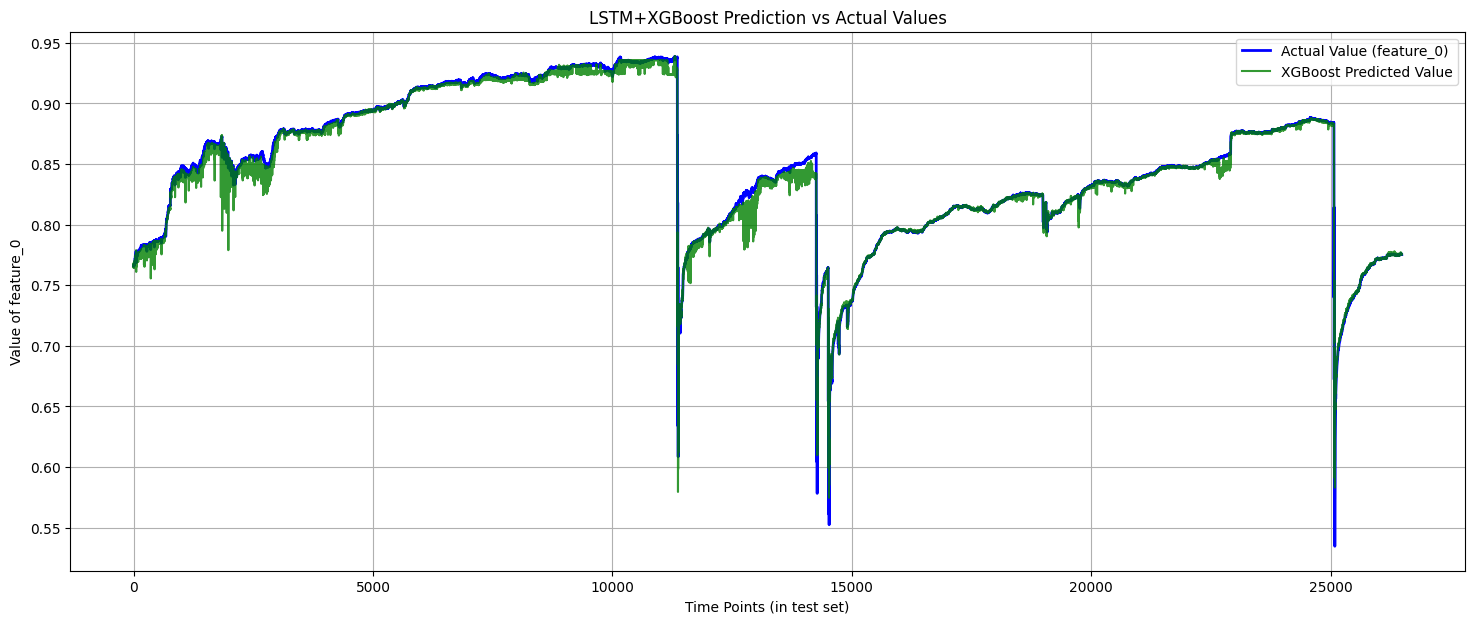

In [9]:
# Evaluate the XGBoost Model

print("Making predictions with XGBoost...")
# Make predictions on the test set features
xgb_predictions = xgb_regressor.predict(X_test_features)

# Calculate the Root Mean Squared Error for the XGBoost model
xgb_rmse = np.sqrt(mean_squared_error(y_test_for_xgb, xgb_predictions))
print(f'\nOriginal LSTM Test RMSE: {rmse:.5f}')
print(f'LSTM + XGBoost Test RMSE: {xgb_rmse:.5f}')

# --- Visualize the results ---
plt.figure(figsize=(18, 7))
plt.plot(y_test_for_xgb, color='blue', label='Actual Value (feature_0)', linewidth=2)
plt.plot(xgb_predictions, color='green', label='XGBoost Predicted Value', alpha=0.8)
plt.title('LSTM+XGBoost Prediction vs Actual Values')
plt.xlabel('Time Points (in test set)')
plt.ylabel('Value of feature_0')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Cell 10: Save Model and Scalers for Future Use

import pickle

# --- Save the trained Keras LSTM model ---
# The '.keras' format is the modern, recommended way to save models.
model.save('lstm_model.keras')
print("Keras LSTM model saved as 'lstm_model.keras'")

# --- Save the scalers using pickle ---
# We need to save BOTH scalers to process new data correctly.
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(feature_scaler, f)
print("Feature scaler saved as 'feature_scaler.pkl'")

with open('target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)
print("Target scaler saved as 'target_scaler.pkl'")

Keras LSTM model saved as 'lstm_model.keras'
Feature scaler saved as 'feature_scaler.pkl'
Target scaler saved as 'target_scaler.pkl'


In [11]:
# Cell 11: Create a Function for Real-World Prediction

from tensorflow.keras.models import load_model

def predict_next_step(new_data_chunk, model, feature_scaler, target_scaler):
    """
    Predicts the next value of 'feature_0' given a chunk of recent historical data.

    Args:
        new_data_chunk (pd.DataFrame): A DataFrame containing the last 60 time steps of data.
                                       It MUST have the 25 feature columns ('feature_0' to 'feature_24').
        model (tf.keras.Model): The trained LSTM model.
        feature_scaler (MinMaxScaler): The scaler that was fitted on the training features.
        target_scaler (MinMaxScaler): The scaler that was fitted on the training target ('feature_0').

    Returns:
        float: The predicted value of 'feature_0' for the next time step.
    """
    if len(new_data_chunk) != 60:
        raise ValueError(f"Input data chunk must have exactly 60 rows, but got {len(new_data_chunk)}")

    # 1. Extract feature values and scale them
    features = new_data_chunk[[f'feature_{i}' for i in range(25)]].values
    scaled_features = feature_scaler.transform(features)

    # 2. Reshape the data into a single sequence for the model
    # Shape should be (1, 60, 25)
    input_sequence = np.reshape(scaled_features, (1, 60, 25))

    # 3. Make a prediction (the output will be scaled)
    scaled_prediction = model.predict(input_sequence)

    # 4. Inverse transform the prediction to get the real value
    real_prediction = target_scaler.inverse_transform(scaled_prediction)

    # The output of inverse_transform is a 2D array, e.g., [[value]], so we extract the number
    return real_prediction[0][0]

# --- Example Usage ---
# Let's load our saved model and scalers to simulate a real-world scenario
loaded_model = load_model('lstm_model.keras')

with open('feature_scaler.pkl', 'rb') as f:
    loaded_feature_scaler = pickle.load(f)

with open('target_scaler.pkl', 'rb') as f:
    loaded_target_scaler = pickle.load(f)

# Now, let's take a sample chunk of data to test our function.
# We'll take the LAST 60 rows from our original dataframe 'df' that were NOT used for testing.
# This simulates having 60 minutes of new, unseen data.
last_60_points_before_test = df.iloc[-len(X_test) - 60 : -len(X_test)]

# Use our function to make a prediction
predicted_value = predict_next_step(
    last_60_points_before_test,
    loaded_model,
    loaded_feature_scaler,
    loaded_target_scaler
)

# Let's see what the actual next value was
actual_value = df.iloc[-len(X_test)]['feature_0']


print(f"\n--- Prediction Test ---")
print(f"Predicted next value for feature_0: {predicted_value:.5f}")
print(f"Actual next value for feature_0:    {actual_value:.5f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step

--- Prediction Test ---
Predicted next value for feature_0: 0.76976
Actual next value for feature_0:    0.76601


In [12]:
# Cell 12: Calculate Prediction Error (Anomaly Score)

# We already have these from Cell 6:
# y_test_actual: The true values from the test set.
# predictions: The LSTM model's predictions for the test set.

# Create a DataFrame to make analysis easier
results = pd.DataFrame({
    'actual': y_test_actual.flatten(),
    'predicted': predictions.flatten()
})

# Calculate the absolute error between actual and predicted values
results['error'] = np.abs(results['actual'] - results['predicted'])

print("Results DataFrame with prediction error:")
print(results.head())

Results DataFrame with prediction error:
     actual  predicted     error
0  0.766006   0.769758  0.003752
1  0.766159   0.767762  0.001603
2  0.766021   0.768884  0.002863
3  0.766044   0.770180  0.004136
4  0.765796   0.768959  0.003163


In [13]:
# Cell 13: Determine a Statistical Anomaly Threshold

# Calculate the mean and standard deviation of the prediction error
mean_error = results['error'].mean()
std_error = results['error'].std()

# Set our anomaly threshold. A value of 3 standard deviations is a common starting point.
anomaly_threshold = mean_error + (std_error * 3)

print(f"Mean of Prediction Error:  {mean_error:.5f}")
print(f"Std Dev of Prediction Error: {std_error:.5f}")
print(f"Anomaly Threshold set at:    {anomaly_threshold:.5f} (Mean + 3*StdDev)")

Mean of Prediction Error:  0.00116
Std Dev of Prediction Error: 0.00296
Anomaly Threshold set at:    0.01004 (Mean + 3*StdDev)


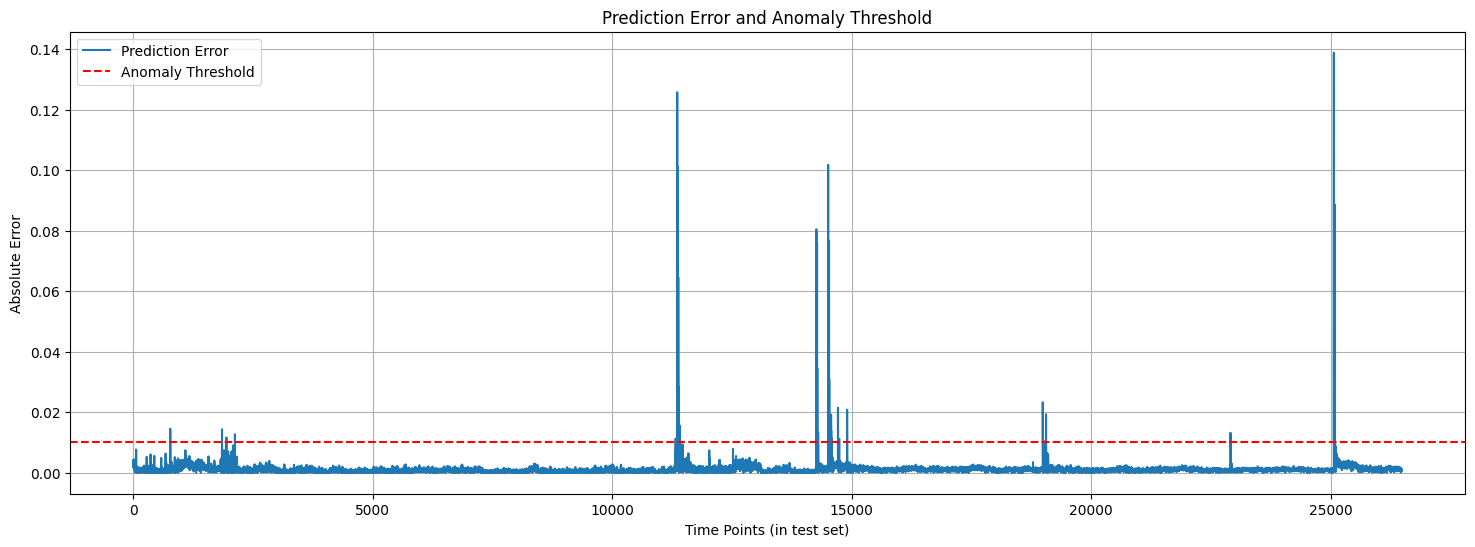

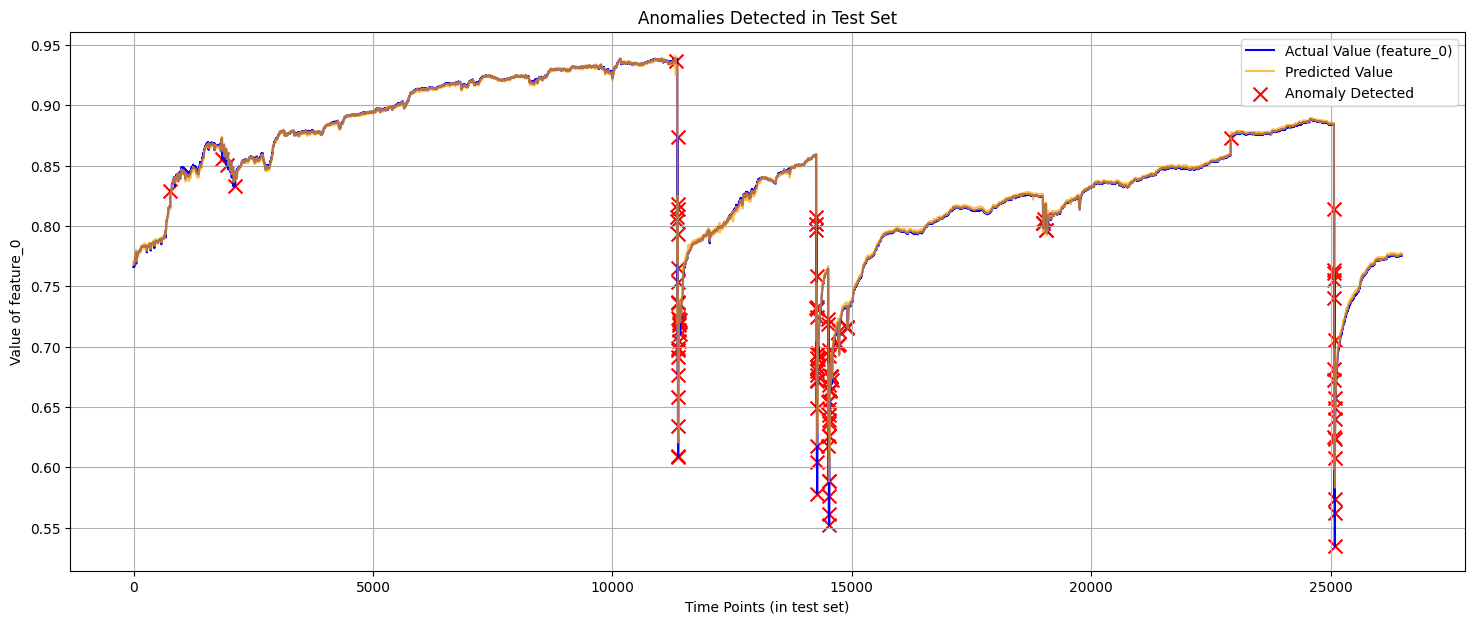


Total anomalies detected: 110


In [14]:
# Cell 14: Identify and Visualize Anomalies

# --- Plot 1: Visualize the Errors and the Threshold ---
plt.figure(figsize=(18, 6))
plt.plot(results['error'], label='Prediction Error')
plt.axhline(y=anomaly_threshold, color='r', linestyle='--', label='Anomaly Threshold')
plt.title('Prediction Error and Anomaly Threshold')
plt.xlabel('Time Points (in test set)')
plt.ylabel('Absolute Error')
plt.legend()
plt.grid(True)
plt.show()


# --- Plot 2: Visualize the Anomalies on the Original Data ---

# Get the data points where the error is greater than the threshold
anomalies = results[results['error'] > anomaly_threshold]

plt.figure(figsize=(18, 7))
# Plot the actual values
plt.plot(results['actual'], color='blue', label='Actual Value (feature_0)')
# Plot the model's predictions
plt.plot(results['predicted'], color='orange', label='Predicted Value', alpha=0.7)

# Highlight the anomalies by plotting them as red 'x' markers
plt.scatter(anomalies.index, anomalies['actual'], color='red', marker='x', s=100, label='Anomaly Detected')

plt.title('Anomalies Detected in Test Set')
plt.xlabel('Time Points (in test set)')
plt.ylabel('Value of feature_0')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nTotal anomalies detected: {len(anomalies)}")